# Generation and Calibration of a CVS model

This notebook walks through the end-to-end workflow for generating, simulating, and calibrating a Cariovascular System (CVS) model, then extending to a 0D-1D hybrid .

## Big Picture Aim

We want to be able to easily generate system models from CellML, tailored towards a specific use-case (number of vessels, 0D or 1D, complexity, control modules, etc), then calibrate the model to clinical data. Calibration is often difficult with a large parameter set, therefore, we use sensitivity analysis to find the most important parameters to calibrate.

## What you will learn

- How to use tools for generating and adapting CVS models

- How to select features for reliable sensitivity analysis.

- How to run sensitivity analysis and calibration in 

## Steps overview
### Section A
- 1-3   Model generation
- 4-5   Simulation of generated models
- 6     Model modification in PhLynx
### Section B
- 7-12  Sensitivity Analysis
- 13-14 Model Calibration
### Section C
- 15-.....


![optional caption](diagram_cvs_model_without_left_arm.png)

# Section A: 0D CVS model generation and simulation
## 1) Set up imports and paths

In [1]:
# Core imports
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
matplotlib.use('module://ipykernel.pylab.backend_inline')
import matplotlib.pyplot as plt
try:
    import opencor as oc
except:
    print('opencor not available, open this jupyter notebook with a python version that has opencor installed')
    exit()

print("Imports done")

# get dir where this file is. This should work locally or in Docker
this_dir = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
CA_root = Path(__file__).resolve().parent.parent.parent if "__file__" in globals() else Path.cwd().parent.parent
#################### TODO make this automatic in Docker ####################################

src_path = os.path.join(CA_root, "src")
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# Set up paths
resources_dir = os.path.join(CA_root, "resources") 
generated_models_dir = os.path.join(CA_root, "generated_models")
param_id_output_dir = os.path.join(CA_root, "param_id_output")
downloads_dir = os.path.join(Path.home(), "Downloads")

print("Paths done")

/opt/OpenCOR/Python/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/opt/OpenCOR/Python/lib/python3.12/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Imports done
Paths done


## 2) Open vessel array in PhLynx (manual) to visualise the model

- Open the cvs_model_0d vessel array in PhLynx [https:/phlynx.com].
- You could also modify, create, and rearrange modules in PhLynx (see tutorial/interactive/image_to_hemodynamics.ipynb)

## 3) Get default settings

In [2]:
from utilities.utility_funcs import get_default_inp_data_dict
import pprint
# Model identifiers
model_name = "cvs_model"
# file_prefix = "3compartment" 
file_prefix = model_name+"_0d" 
input_param_file = f"{file_prefix}_parameters.csv"

# Base user inputs (this shows all the settings that can be changed)
inp_data_dict = get_default_inp_data_dict(file_prefix, input_param_file, resources_dir)

# TEMPORARY FOR THIS TUTORIAL
inp_data_dict['DEBUG'] = True

print('inp_data_dict set')
pprint.pprint(inp_data_dict)


Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified



sim_time not found in inp_data_dict, setting to None so it can be set in protocol_info
inp_data_dict set
{'DEBUG': True,
 'couple_to_1d': False,
 'do_ia': False,
 'dt': 0.01,
 'external_modules_dir': None,
 'file_prefix': 'cvs_model_0d',
 'generated_models_dir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models',
 'generated_models_subdir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_0d',
 'ia_options': {'method': 'Laplace'},
 'input_param_file': 'cvs_model_0d_parameters.csv',
 'model_path': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_0d/cvs_model_0d.cellml',
 'model_type': 'cellml_only',
 'optimiser_options': {},
 'param_id_method': 'genetic_algorithm',
 'param_id_output_dir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../param_id_output',
 'parameters_csv_abs_path': '/tuto

In [3]:
from scripts.script_generate_with_new_architecture import generate_with_new_architecture
import shutil

# Generate directly from resources CSVs
success = generate_with_new_architecture(inp_data_dict=inp_data_dict)

if not success:
    raise RuntimeError("Model generation failed")
else:
    print('Model generation successful')



/opt/OpenCOR/Python/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/opt/OpenCOR/Python/lib/python3.12/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


Check point 0


Generating model files at /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_0d
Generating CellML file cvs_model_0d_units.cellml
Generating CellML file cvs_model_0d.cellml
writing units mapping
writing imports
writing vessel mappings
writing environment to sum venous input flows
writing environment to sum generic junctions input flows
writing environment to apply operations for multiports
writing variable access
writing global params variable access
writing mappings between computational environment and modules
writing mappings between computational environment and modules for global parameters
writing mappings between constant params
writing writing time mappings between environment and modules
Generating CellML file cvs_model_0d_parameters.cellml
Generating modules file cvs_model_0d_modules.cellml
Model generation complete.
Checking Status of Model
The method "parse_model" found 82 issues:
    - Given model is a

## 4) Load the model with SimulationHelper

Use the solver wrapper to load the CellML model and prepare a simulation helper.

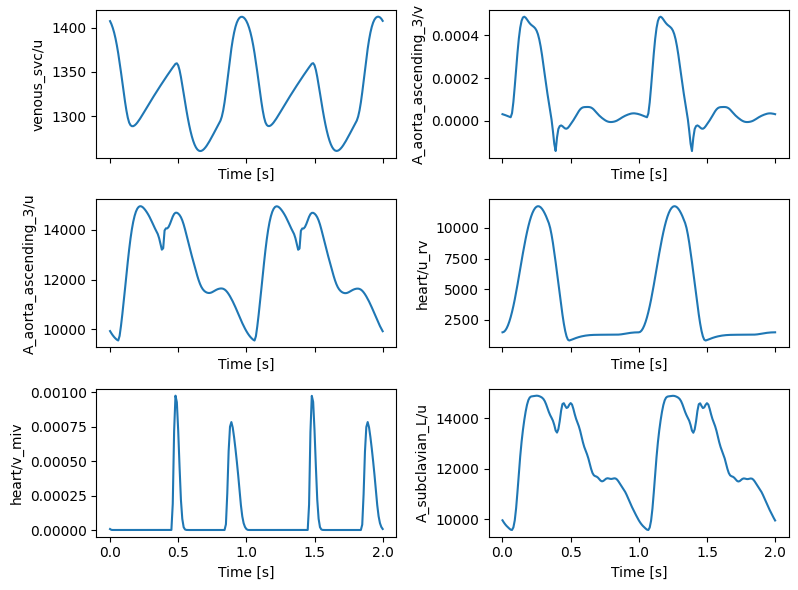

In [4]:
from solver_wrappers import get_simulation_helper_from_inp_data_dict

# Simulation settings
inp_data_dict["sim_time"] = 2 # the 2 seconds we care about
inp_data_dict["pre_time"] = 20.0 # simulate for 20 seconds to get to periodic steady state

sim_helper = get_simulation_helper_from_inp_data_dict(inp_data_dict)

# Run once and plot a few representative variables
sim_helper.run()
variables_to_plot = [
    "venous_svc/u",
    "A_aorta_ascending_3/v",
    "A_aorta_ascending_3/u",
    "heart/u_rv",
    "heart/v_miv",
    "A_subclavian_L/u"
]

y = sim_helper.get_results(variables_to_plot, flatten=True)
t = sim_helper.get_time()

##### Plotting #####

plot_dir = Path(param_id_output_dir) / "quicklooks"
plot_dir.mkdir(parents=True, exist_ok=True)

fig, axs = plt.subplots(3, 2, sharex=True, figsize=(8, 6))
axs = axs.flatten()
for idx, (ax, series, name) in enumerate(zip(axs, y, variables_to_plot)):
    ax.plot(t, series)
    ax.set_ylabel(name)
    ax.set_xlabel("Time [s]")

plt.tight_layout()
plt.savefig(plot_dir / "uncalibrated_outputs.png")
plt.show()

## STUDENT TASK

- We want to have a model which predicts pressure dynamics accurately! 
- Write here what you think the most important features of the pressure trace are.

##  Most important Features specified here:
# -----------------------
-
-
-
#  -----------------------



## 5) Plot ground-truth data vs uncalibrated outputs

Load the ground-truth data and compare it to the uncalibrated simulation results.

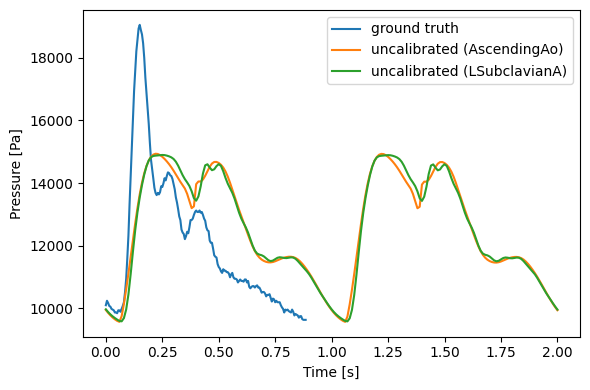

In [5]:
# TODO: update with your ground-truth data file
# Example assumes a CSV with a time column and measurement columns
# intervention = 'rest'  #Available interventions: rest, 6bpm
intervention = '6_breath_per_min'

ground_truth_file = (
    Path(this_dir)
    / "resources"
    / f"pressure_finger_{intervention}.csv"
)
# ground_truth_file = os.path.join(this_dir, "resources", "aorta_pressure_temp.txt")

if os.path.exists(ground_truth_file):
    gt = pd.read_csv(ground_truth_file) #, sep="\t")

    time_col = list(gt.keys())[0] #"time_s"
    var_col = list(gt.keys())[1] #"pressure_mmHg"

    time_gt = gt[time_col].to_numpy()
    pressure_pa = gt[var_col].to_numpy() * 133.322  # mmHg -> Pa

    plt.figure(figsize=(6, 4))
    plt.plot(time_gt, pressure_pa, label="ground truth")
    plt.plot(t, y[2], label="uncalibrated (AscendingAo)")
    plt.plot(t, y[5], label="uncalibrated (LSubclavianA)")
    plt.xlabel("Time [s]")
    plt.ylabel("Pressure [Pa]")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Ground-truth file not found: {ground_truth_file}")

## 6) Add left arm vessels in PhLynx (manual)

Add arm vessels in PhLynx [https://phlynx.com].

- Each new artery must be coupled to the "K_tube" module for its material properties.
- The "arm_L_T" terminal compartment is now placed at the point where the subclavian artery becomes axillary artery.
- Each common palmar digital artery is coupled to its "hand_L_X_T" terminal compartment.
- All terminal compartments converge into the original "venous_arm_L_T" venous compartment.

From PhLynx, save the new vessel array file as cvs_model_with_arm_0d_vessel_array.csv in resources_dir.

## TODO adjust paths here.

![optional caption](diagram_left_arm_network.png)

## 7) Generate the new model
### Update/fill missing model parameters

- Open the parameters file for the extended CVS model: cvs_model_with_arm_0d_parameters_TO_FILL.csv
- Locate the missing parameters (value=-999 | data_reference=EMPTY_MUST_BE_FILLED)
- Calculate baseline (pre-calibration) terminal resistances $R_{\alpha}$ and compliances $C_{\alpha}$ for $\alpha\in\,${arm_L_T, hand_L_1_T, hand_L_2_T, hand_L_3_T} by splitting the original terminal resistance and compliance of the "arm_L_T" compartment, assuming that $R=(P_{\rm art}-P_{\rm ven})/Q$ and $C\propto Q$, and that the original blood flow fraction to arm_L_T splits into 60% to the upper arm and 40% to the forearm, which in turn splits equally among the three hand compartments.
- Save the complete parameters file as: cvs_model_with_arm_0d_parameters.csv

### Generate the model
- Regenerate the CellML model.
- If you exported a new CellML file, re-run the copy/generation cell above.

In [6]:
model_name_ext = model_name+"_with_arm"
file_prefix = model_name_ext+"_0d"
input_param_file = f"{file_prefix}_parameters.csv"

inp_data_dict = get_default_inp_data_dict(file_prefix, input_param_file, resources_dir)

# TEMPORARY FOR THIS TUTORIAL
inp_data_dict['DEBUG'] = True

print('inp_data_dict set')
pprint.pprint(inp_data_dict)


sim_time not found in inp_data_dict, setting to None so it can be set in protocol_info
inp_data_dict set
{'DEBUG': True,
 'couple_to_1d': False,
 'do_ia': False,
 'dt': 0.01,
 'external_modules_dir': None,
 'file_prefix': 'cvs_model_with_arm_0d',
 'generated_models_dir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models',
 'generated_models_subdir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_with_arm_0d',
 'ia_options': {'method': 'Laplace'},
 'input_param_file': 'cvs_model_with_arm_0d_parameters.csv',
 'model_path': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_with_arm_0d/cvs_model_with_arm_0d.cellml',
 'model_type': 'cellml_only',
 'optimiser_options': {},
 'param_id_method': 'genetic_algorithm',
 'param_id_output_dir': '/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../param_i

In [7]:
# THIS CELL CAN BE EMPTY AND THE STUDENT CAN COPY AND PASTE THE GENERATION STEPS FROM ABOVE
# Generate directly from resources CSVs
success = generate_with_new_architecture(inp_data_dict=inp_data_dict)

if not success:
    raise RuntimeError("Model generation failed")
else:
    print('Model generation successful')
    

Check point 0


Generating model files at /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../generated_models/cvs_model_with_arm_0d
Generating CellML file cvs_model_with_arm_0d_units.cellml
Generating CellML file cvs_model_with_arm_0d.cellml
writing units mapping
writing imports
writing vessel mappings
writing environment to sum venous input flows
writing environment to sum generic junctions input flows
writing environment to apply operations for multiports
writing variable access
writing global params variable access
writing mappings between computational environment and modules
writing mappings between computational environment and modules for global parameters
writing mappings between constant params
writing writing time mappings between environment and modules
Generating CellML file cvs_model_with_arm_0d_parameters.cellml
Generating modules file cvs_model_with_arm_0d_modules.cellml
Model generation complete.
Checking Status of Model
The method "parse_m

# Section B: Sensitivity analysis & model calibration

## 8) Create a parameter identification object
Create a parameter identification object which will be used to set up your calibration problem.

In [8]:
from param_id.paramID import CVS0DParamID

# first create a a param id object which will be used to set up out calibration problem
solver_info = {
    "dt_solver": 0.01,
}

inp_data_dict['solver_info'] = solver_info

param_id = CVS0DParamID.init_from_dict(inp_data_dict)
print("param id initialised")


param id initialised


## 9) Set the observable data
Set the observable data that you want to calibrate towards.

In [9]:
from utilities.obs_data_helpers import ObsDataCreator

# now create the obs data creator object for creating a dictionary that contains the data you will fit towards
obs_data_creator = ObsDataCreator()

# Protocol info (this defines your times and changes of inputs in the experiment)
pre_times = [20] # the pre time for each experiment
sim_times = [[time_gt[-1]]] # the sim time for each subexperiment
obs_dt = time_gt[1]-time_gt[0]
params_to_change = {}
obs_data_creator.add_protocol_info(pre_times, sim_times, params_to_change)

# add an entry for just fitting the mean of the pressure
# TODO replace with one of the arm vessels added, based on the measurement location of the GT pressure data
entry = {
    "variable": "P aortic root mean",
    "name_for_plotting": "P_{aoMean}",
    "operands": ["A_aorta_ascending_3/u"],
    "operation": "mean",
    "unit": "Pa",
    "value": np.mean(pressure_pa),
    "std": 200, # assumed std of the mean pressure
    "obs_dt": obs_dt,
    "plot_type": None
}
obs_data_creator.add_data_item(entry)
    

obs_data_dict = obs_data_creator.get_obs_data_dict()

# pprint.pprint(obs_data_dict)

# now add the obs to the param id object
param_id.set_ground_truth_data(obs_data_dict)


Setting ground truth data: {'protocol_info': {'pre_times': [20], 'sim_times': [[0.8849]], 'params_to_change': {}, 'experiment_labels': ['exp_0']}, 'prediction_items': [], 'data_items': [{'variable': 'P aortic root mean', 'name_for_plotting': 'P_{aoMean}', 'operands': ['A_aorta_ascending_3/u'], 'operation': 'mean', 'unit': 'Pa', 'value': 12042.904576206001, 'std': 200, 'obs_dt': 0.005, 'plot_type': None, 'weight': 1.0, 'subexperiment_idx': 0, 'experiment_idx': 0, 'data_type': 'constant'}]}
Ground truth data set: {'obs_names': ['P aortic root mean'], 'data_types': ['constant'], 'units': ['Pa'], 'experiment_idxs': [0], 'subexperiment_idxs': [0], 'plot_colors': ['b'], 'plot_type': [None], 'operations': ['mean'], 'operands': [['A_aorta_ascending_3/u']], 'operation_kwargs': [{}], 'freqs': [None], 'names_for_plotting': ['P_{aoMean}'], 'num_obs': 1, 'weight_const_vec': array([1.]), 'weight_series_vec': array([], dtype=float64), 'weight_amp_vec': array([], dtype=float64), 'weight_prob_dist_vec'

## 10) Create params_for_id.csv from Python


In [10]:
# These vessels will have their stiffness calibrated
vessels_to_calibrate_stiffness = ["K_tube_A_aorta_ascending_1", "K_tube_A_aorta_ascending_2", 
                               "K_tube_A_aorta_ascending_3", "K_tube_A_aorta_ascending_4",
                               "K_tube_A_aortic_arch_1", "K_tube_A_aortic_arch_2", "K_tube_A_aortic_arch_3"]

# These vein compartments will have their compliance calibrated
vein_compartments_to_calibrate_compliance = ["venous_svc", "venous_ivc", 
                                             "venous_head_L_T","venous_head_R_T", 
                                             "venous_arm_L_T","venous_arm_R_T",
                                             "venous_leg_L_T","venous_leg_R_T",
                                             "venous_trunk_C_T"]

params_for_id_dict = [
    {
        "vessel_name": "global", 
        "param_name": "q_lv_init", # we need to initialise blood volume somewhere, here we do it in the left ventricle for 
                                   # ease of implementation. This will be pumped around the body to 
                                   # give realistic volumes throughout the CVS.
                                   # Think of this as a parameter that shifts the total blood volume.
        "min": 400e-6,
        "max": 2500e-6,
        "name_for_plotting": "q_{sbv}", 
    },
    {
        "vessel_name": vessels_to_calibrate_stiffness,
        "param_name": "E",  # This is the Young's modulus for the arterial vessels
        "min": 4e+4,
        "max": 8e+5,
        "name_for_plotting": "E_{ao}",
    },
    {
        "vessel_name": vein_compartments_to_calibrate_compliance,
        "param_name": "C",  # This is the compliance for the venous vessels
        "min": 1e-7, 
        "max": 4e-7,
        "name_for_plotting": "C_{v}",
    }
]

print(params_for_id_dict)

# now add the params to the param id object
param_id.set_params_for_id(params_for_id_dict)


[{'vessel_name': 'global', 'param_name': 'q_lv_init', 'min': 0.0004, 'max': 0.0025, 'name_for_plotting': 'q_{sbv}'}, {'vessel_name': ['K_tube_A_aorta_ascending_1', 'K_tube_A_aorta_ascending_2', 'K_tube_A_aorta_ascending_3', 'K_tube_A_aorta_ascending_4', 'K_tube_A_aortic_arch_1', 'K_tube_A_aortic_arch_2', 'K_tube_A_aortic_arch_3'], 'param_name': 'E', 'min': 40000.0, 'max': 800000.0, 'name_for_plotting': 'E_{ao}'}, {'vessel_name': ['venous_svc', 'venous_ivc', 'venous_head_L_T', 'venous_head_R_T', 'venous_arm_L_T', 'venous_arm_R_T', 'venous_leg_L_T', 'venous_leg_R_T', 'venous_trunk_C_T'], 'param_name': 'C', 'min': 1e-07, 'max': 4e-07, 'name_for_plotting': 'C_{v}'}]
Setting params for id: [{'vessel_name': 'global', 'param_name': 'q_lv_init', 'min': 0.0004, 'max': 0.0025, 'name_for_plotting': 'q_{sbv}'}, {'vessel_name': ['K_tube_A_aorta_ascending_1', 'K_tube_A_aorta_ascending_2', 'K_tube_A_aorta_ascending_3', 'K_tube_A_aorta_ascending_4', 'K_tube_A_aortic_arch_1', 'K_tube_A_aortic_arch_2', 

## STUDENT TASK

Write down what outputs of the CVS model (pressures? flows? features of pressure/flow traces, in which location?) you think each parameter will affect. Compare this with outputs later.

# -----------------------
-
-
-
#  -----------------------



## 11) Sensitivity analysis

Run Sobol sensitivity analysis over a large parameter set and save outputs to a defined directory.


In [11]:
from sensitivity_analysis.sensitivityAnalysis import SensitivityAnalysis
import shutil

sa_output_dir = Path(param_id_output_dir) / "sensitivity" / file_prefix
if sa_output_dir.exists():
    shutil.rmtree(sa_output_dir) # remove the directory if it exists
sa_output_dir.mkdir(parents=True, exist_ok=True)


sa_options = {
    "method": "sobol",
    "sample_type": "saltelli",
    "num_samples": 16, # change to 256 for more accurate results
    "output_dir": str(sa_output_dir),
}

sa_agent = SensitivityAnalysis.init_from_dict(inp_data_dict)

sa_agent.set_ground_truth_data(obs_data_dict)
sa_agent.set_params_for_id(params_for_id_dict)
sa_agent.set_sa_options(sa_options)

sa_agent.run_sensitivity_analysis(sa_options)
sa_output_dir


Setting ground truth data: {'protocol_info': {'pre_times': [20], 'sim_times': [[0.8849]], 'params_to_change': {}, 'experiment_labels': ['exp_0'], 'num_experiments': 1, 'num_sub_per_exp': [1], 'num_sub_total': 1, 'total_sim_times_per_exp': [0.8849], 'tSims_per_exp': [array([0.        , 0.01005568, 0.02011136, 0.03016705, 0.04022273,
       0.05027841, 0.06033409, 0.07038977, 0.08044545, 0.09050114,
       0.10055682, 0.1106125 , 0.12066818, 0.13072386, 0.14077955,
       0.15083523, 0.16089091, 0.17094659, 0.18100227, 0.19105795,
       0.20111364, 0.21116932, 0.221225  , 0.23128068, 0.24133636,
       0.25139205, 0.26144773, 0.27150341, 0.28155909, 0.29161477,
       0.30167045, 0.31172614, 0.32178182, 0.3318375 , 0.34189318,
       0.35194886, 0.36200455, 0.37206023, 0.38211591, 0.39217159,
       0.40222727, 0.41228295, 0.42233864, 0.43239432, 0.44245   ,
       0.45250568, 0.46256136, 0.47261705, 0.48267273, 0.49272841,
       0.50278409, 0.51283977, 0.52289545, 0.53295114, 0.543006

Rank 0:  22%|██▏       | 28/128 [00:25<01:54,  1.14s/it]

Failed to converge
restarting simulation object
[MPI Rank 0] Simulation failed for params: [1.121875e-03 6.375000e+04 3.156250e-07], subexp=0 after 0 retries


Rank 0:  23%|██▎       | 29/128 [00:27<02:16,  1.38s/it]

Failed to converge
restarting simulation object
[MPI Rank 0] Simulation failed for params: [1.121875e-03 6.375000e+04 3.156250e-07], subexp=0 after 0 retries


Rank 0: 100%|██████████| 128/128 [01:52<00:00,  1.14it/s]


[MPI Rank 0] Finished processing samples 0:128
[MPI Rank 0] Gathered and flattened all outputs. Total outputs: (128, 1)
Sensitivity analysis completed successfully :)
saving results in /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d

Generating Sobol Index Heatmaps...
Saved First-Order ($S_1$) heatmap to /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d/First_Order ($S_1$)_Sobol_Heatmap.png
Saved Total-Order ($S_T$) heatmap to /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d/Total_Order ($S_T$)_Sobol_Heatmap.png


PosixPath('/tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d')

## 12) View the sensitivity analysis plots

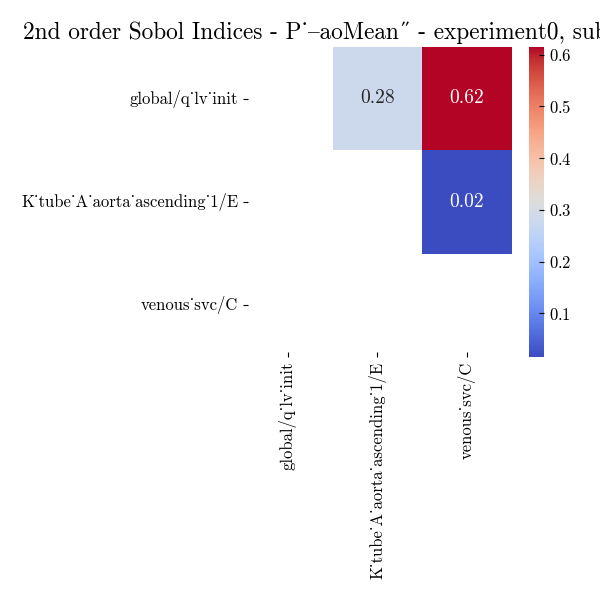

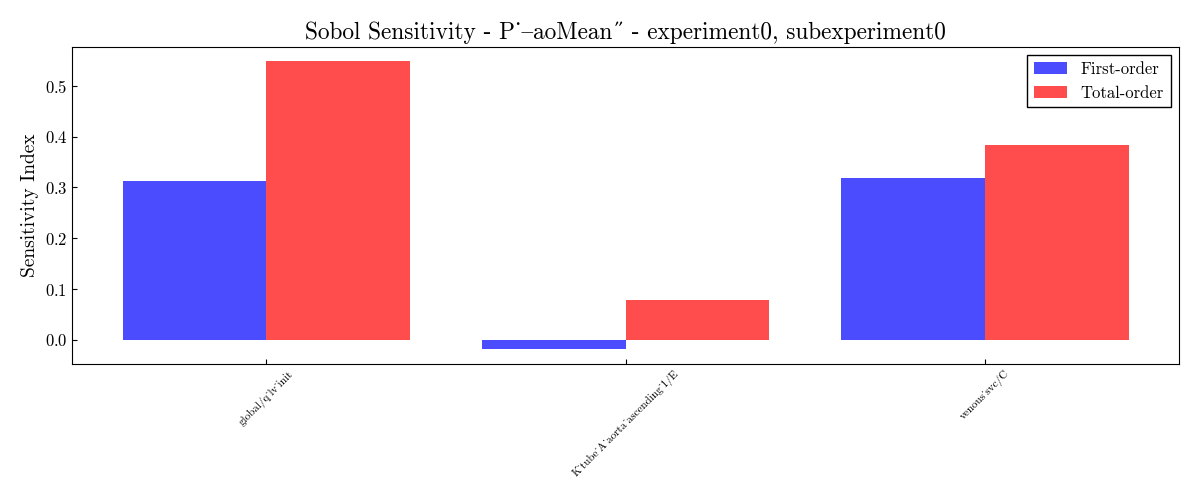

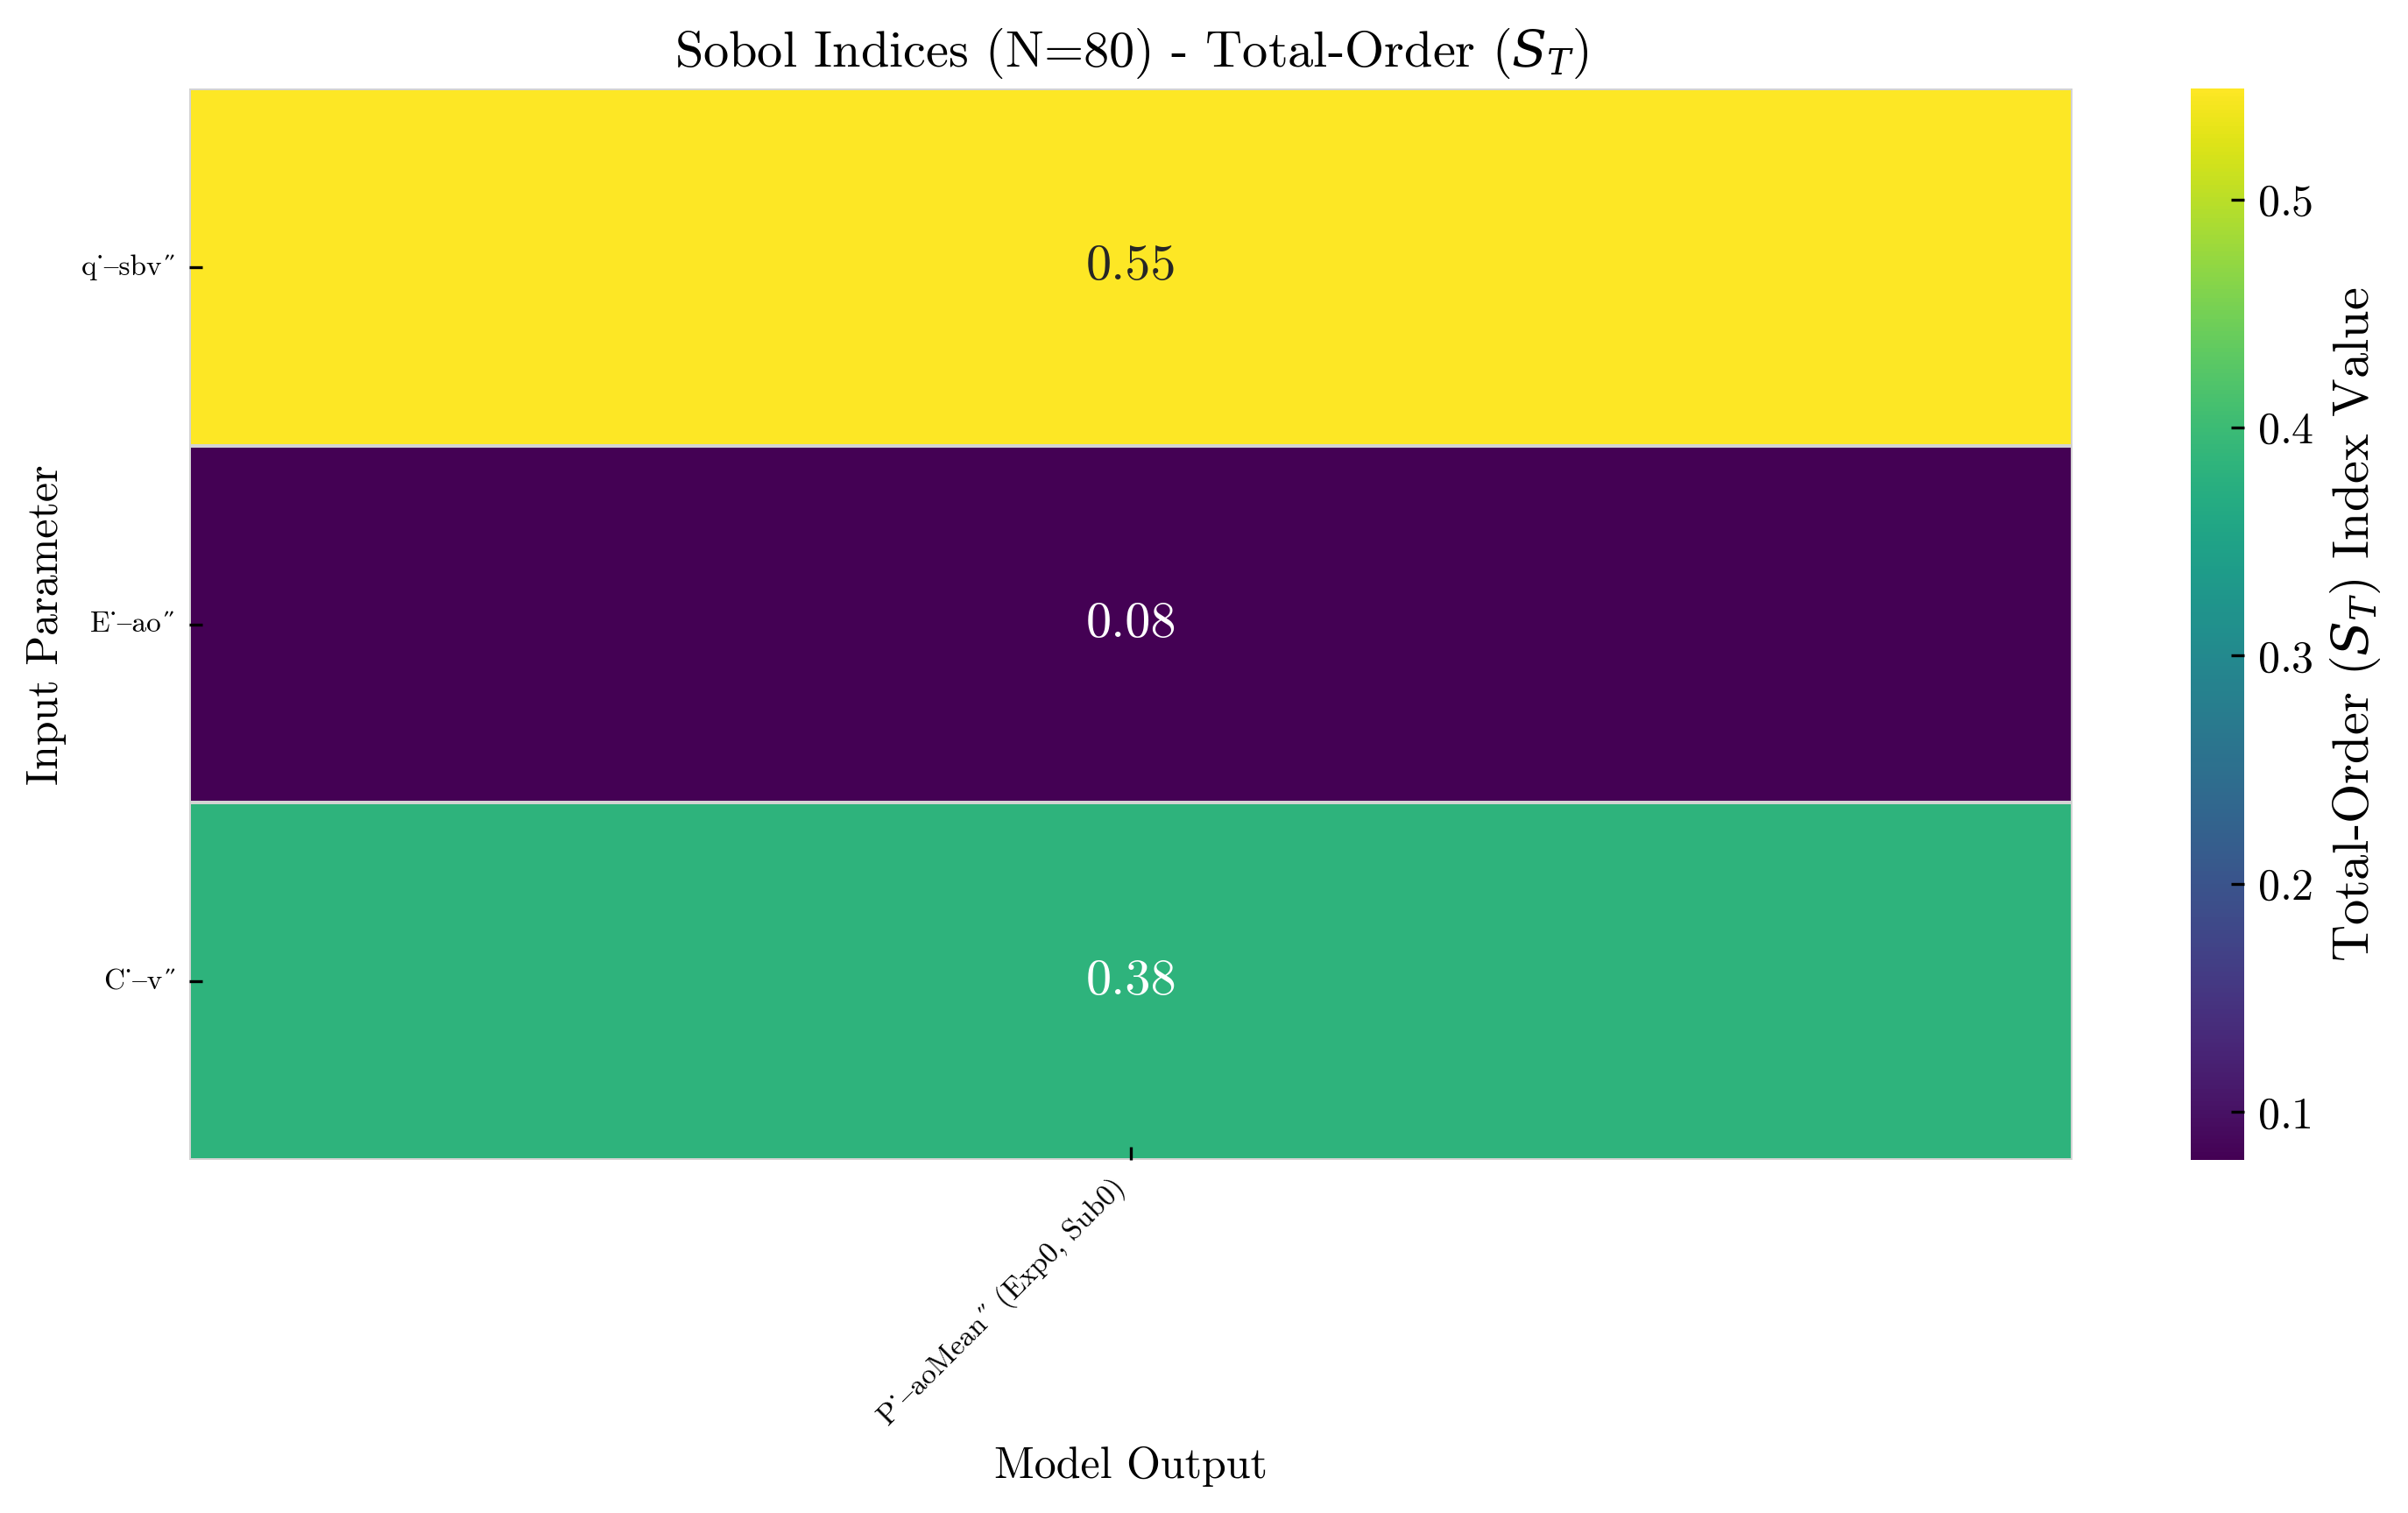

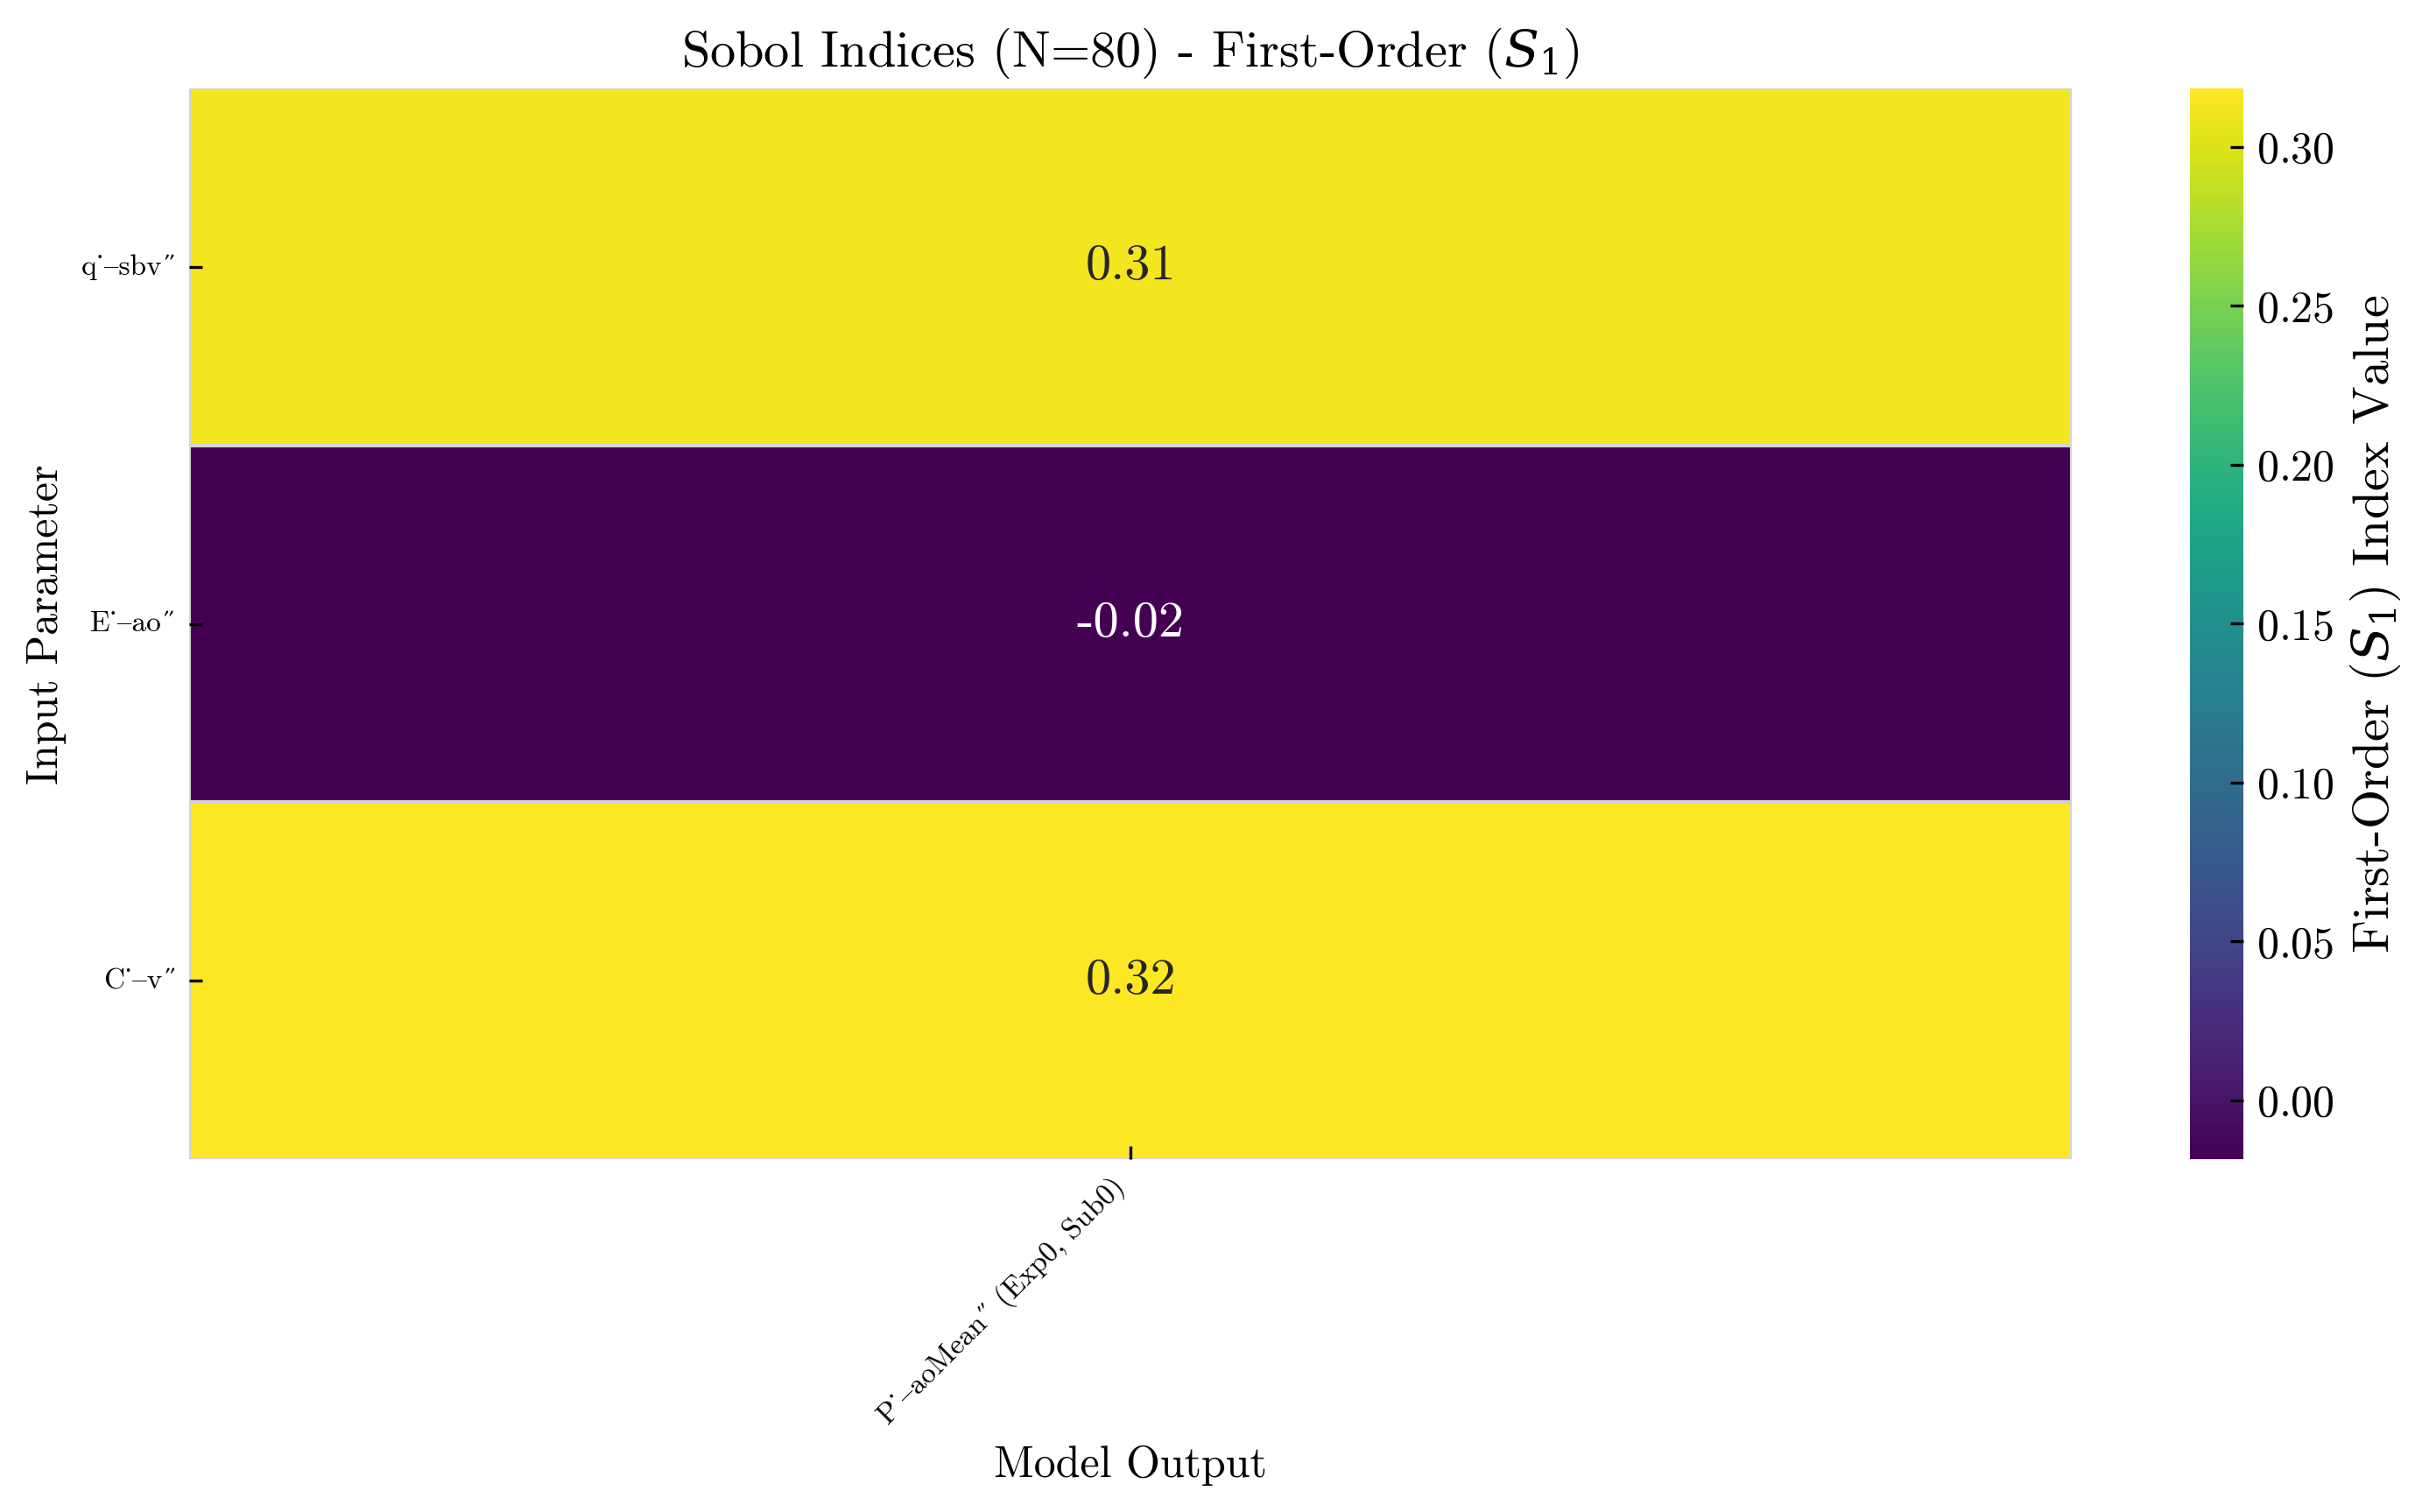

In [12]:
from IPython.display import Image, display

# Display the plots from the sensitivity analysis
plot_files = [file_path for file_path in sa_output_dir.glob("*.png")]
for plot_file in plot_files:
    display(Image(filename=str(plot_file)))


## Questions for Students

- What do you think happens if you change the ranges for your parameters? How do we ensure these ranges are valid?

# STUDENT TASK
- Change the parameter ranges above and rerun to see how it changes your sensitivity analysis results. 

# STUDENT TASK
- Look back at what features you think are important. Now we want to add those features to the outputs we will fit to.
- Write some potential features here.
# ----------
- Max
-
-
# ----------

## 13) Now add your own extra feature to fit to.
### The below is an example of how to add a custom feature to the obs data creator.

## STUDENT TASK
- Modify the below function to extract whatever feature you want! Max? Min? Weights of a certain basis? Anything you want.

In [13]:


# Create your own feature to fit to
def my_extra_feature(time, pressure, series_output=False):
    if series_output: # needed for plotting the series in automatic plots
        return pressure
    feature = None

    # STUDENT TASK: add your own feature here   
    # -----------

    # TODO delete this
    # feature = pressure.max()
    feature = (pressure.max() - pressure.min()) / pressure.mean()
    # -----------
    
    return feature

my_extra_feature.series_to_constant = True # this is needed for plotting the series in automatic plots

sa_agent.add_user_operation_func(my_extra_feature)
param_id.add_user_operation_func(my_extra_feature)

extra_entry = {
    "variable": "P aortic root extra feature",
    "name_for_plotting": "P_{aoExtra}",
    "operands": ["time","A_aorta_ascending_3/u"], # these need to correspond to the operands in my_extra_feature
    "operation": "my_extra_feature",
    "unit": "Pa",
    "value": my_extra_feature(time_gt, pressure_pa), # this uses your function to get the value you want to fit to from the ground truth data
    "std": 0.01, # Set an approximate standard deviation for your feature (should be calculated from the data)
    "plot_type": None, # don't plot this feature
}

# extra_entry = {
#    "variable": "NAME OF YOUR NEW VARIABLE/FEATURE TO EXTRACT",
#    "name_for_plotting": "TO DEFINE",
#    "operands": [INPUTS_TO_YOUR_NEW_FUNCTION], # these need to correspond to the operands in my_extra_feature
#    "operation": "my_extra_feature",
#    "unit": "Pa",
#    "value": my_extra_feature(time_gt, pressure_pa), # this uses your function to get the value you want to fit to from the ground truth data
#    "std": TO_DEFINE, # assumed std of the pressure
#}

obs_data_creator.add_data_item(extra_entry)
obs_data_dict = obs_data_creator.get_obs_data_dict()
obs_data_dict

{'protocol_info': {'pre_times': [20],
  'sim_times': [[0.8849]],
  'params_to_change': {},
  'experiment_labels': ['exp_0'],
  'num_experiments': 1,
  'num_sub_per_exp': [1],
  'num_sub_total': 1,
  'total_sim_times_per_exp': [0.8849],
  'tSims_per_exp': [array([0.        , 0.01005568, 0.02011136, 0.03016705, 0.04022273,
          0.05027841, 0.06033409, 0.07038977, 0.08044545, 0.09050114,
          0.10055682, 0.1106125 , 0.12066818, 0.13072386, 0.14077955,
          0.15083523, 0.16089091, 0.17094659, 0.18100227, 0.19105795,
          0.20111364, 0.21116932, 0.221225  , 0.23128068, 0.24133636,
          0.25139205, 0.26144773, 0.27150341, 0.28155909, 0.29161477,
          0.30167045, 0.31172614, 0.32178182, 0.3318375 , 0.34189318,
          0.35194886, 0.36200455, 0.37206023, 0.38211591, 0.39217159,
          0.40222727, 0.41228295, 0.42233864, 0.43239432, 0.44245   ,
          0.45250568, 0.46256136, 0.47261705, 0.48267273, 0.49272841,
          0.50278409, 0.51283977, 0.52289545, 0

## 14) Run sensitivity analysis with your new feature!

In [14]:

sa_agent.set_ground_truth_data(obs_data_dict)

# remove the old results before running.
if sa_output_dir.exists():
    shutil.rmtree(sa_output_dir) # remove the directory if it exists
sa_output_dir.mkdir(parents=True, exist_ok=True)

sa_agent.run_sensitivity_analysis(sa_options)



Setting ground truth data: {'protocol_info': {'pre_times': [20], 'sim_times': [[0.8849]], 'params_to_change': {}, 'experiment_labels': ['exp_0'], 'num_experiments': 1, 'num_sub_per_exp': [1], 'num_sub_total': 1, 'total_sim_times_per_exp': [0.8849], 'tSims_per_exp': [array([0.        , 0.01005568, 0.02011136, 0.03016705, 0.04022273,
       0.05027841, 0.06033409, 0.07038977, 0.08044545, 0.09050114,
       0.10055682, 0.1106125 , 0.12066818, 0.13072386, 0.14077955,
       0.15083523, 0.16089091, 0.17094659, 0.18100227, 0.19105795,
       0.20111364, 0.21116932, 0.221225  , 0.23128068, 0.24133636,
       0.25139205, 0.26144773, 0.27150341, 0.28155909, 0.29161477,
       0.30167045, 0.31172614, 0.32178182, 0.3318375 , 0.34189318,
       0.35194886, 0.36200455, 0.37206023, 0.38211591, 0.39217159,
       0.40222727, 0.41228295, 0.42233864, 0.43239432, 0.44245   ,
       0.45250568, 0.46256136, 0.47261705, 0.48267273, 0.49272841,
       0.50278409, 0.51283977, 0.52289545, 0.53295114, 0.543006

Rank 0:  21%|██        | 27/128 [00:23<02:00,  1.19s/it]

Failed to converge
restarting simulation object
[MPI Rank 0] Simulation failed for params: [1.121875e-03 6.375000e+04 3.156250e-07], subexp=0 after 0 retries


Rank 0:  23%|██▎       | 29/128 [00:26<02:13,  1.34s/it]

Failed to converge
restarting simulation object
[MPI Rank 0] Simulation failed for params: [1.121875e-03 6.375000e+04 3.156250e-07], subexp=0 after 0 retries


Rank 0: 100%|██████████| 128/128 [01:50<00:00,  1.16it/s]


[MPI Rank 0] Finished processing samples 0:128
[MPI Rank 0] Gathered and flattened all outputs. Total outputs: (128, 2)
Sensitivity analysis completed successfully :)
saving results in /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d

Generating Sobol Index Heatmaps...
Saved First-Order ($S_1$) heatmap to /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d/First_Order ($S_1$)_Sobol_Heatmap.png
Saved Total-Order ($S_T$) heatmap to /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/param_id_output/sensitivity/cvs_model_with_arm_0d/Total_Order ($S_T$)_Sobol_Heatmap.png


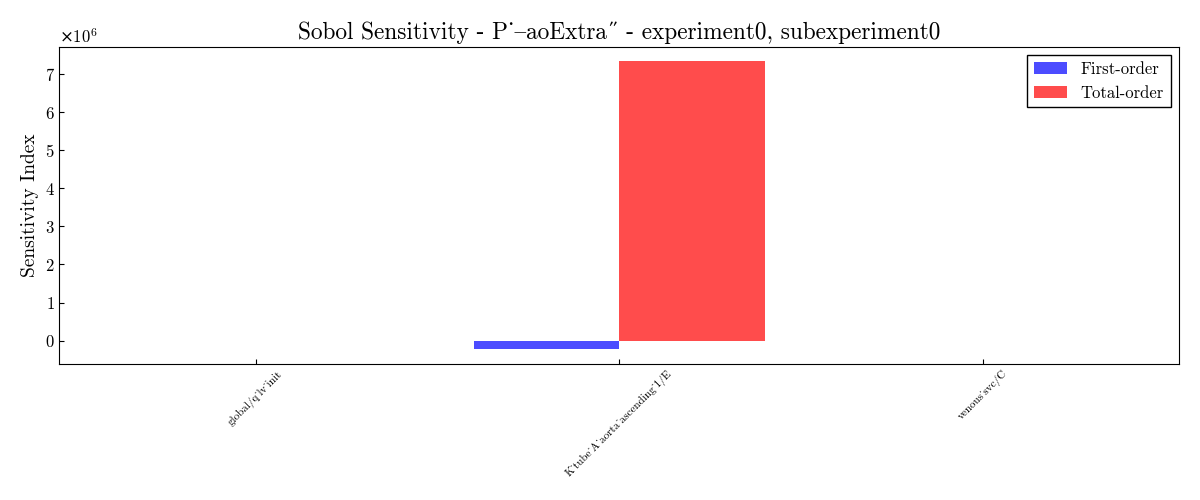

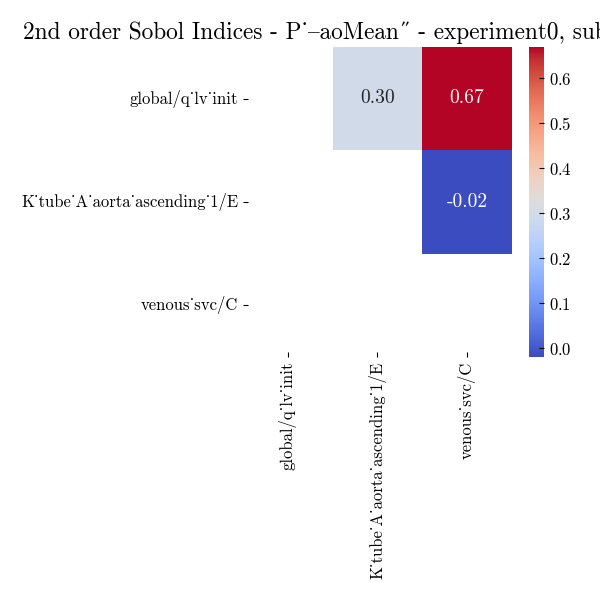

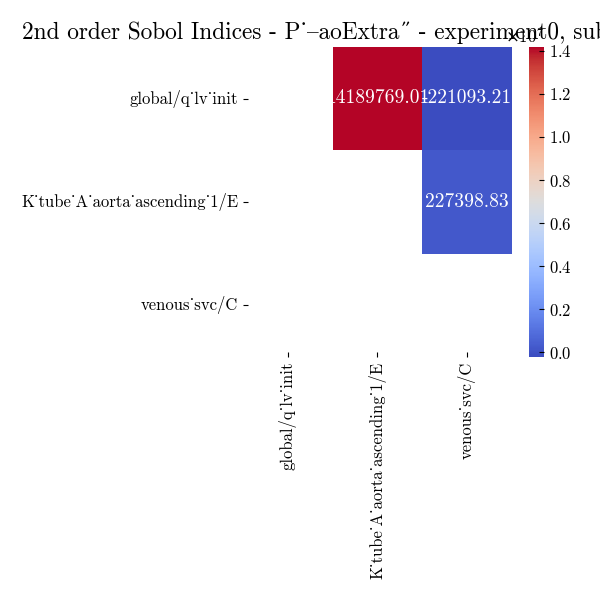

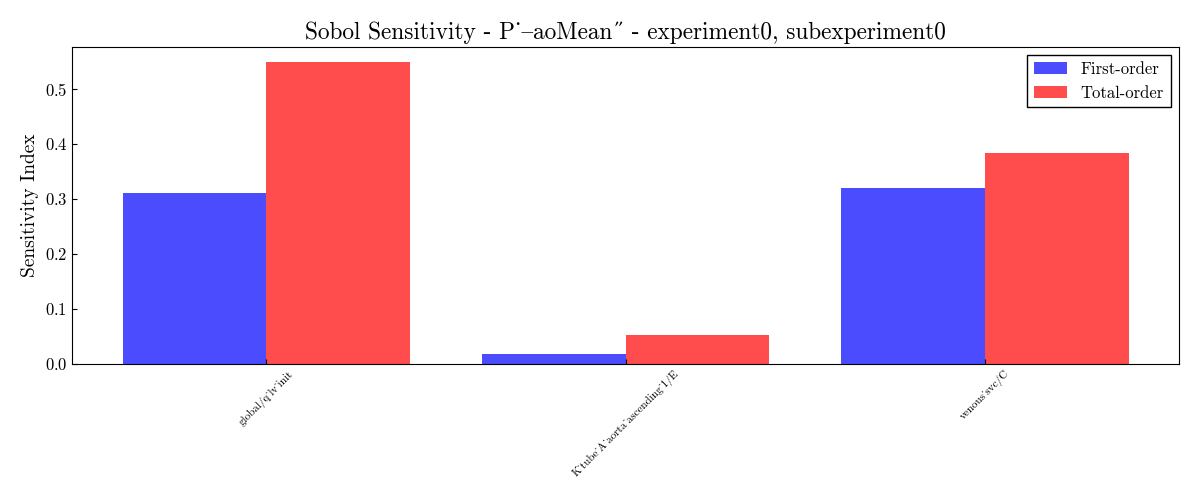

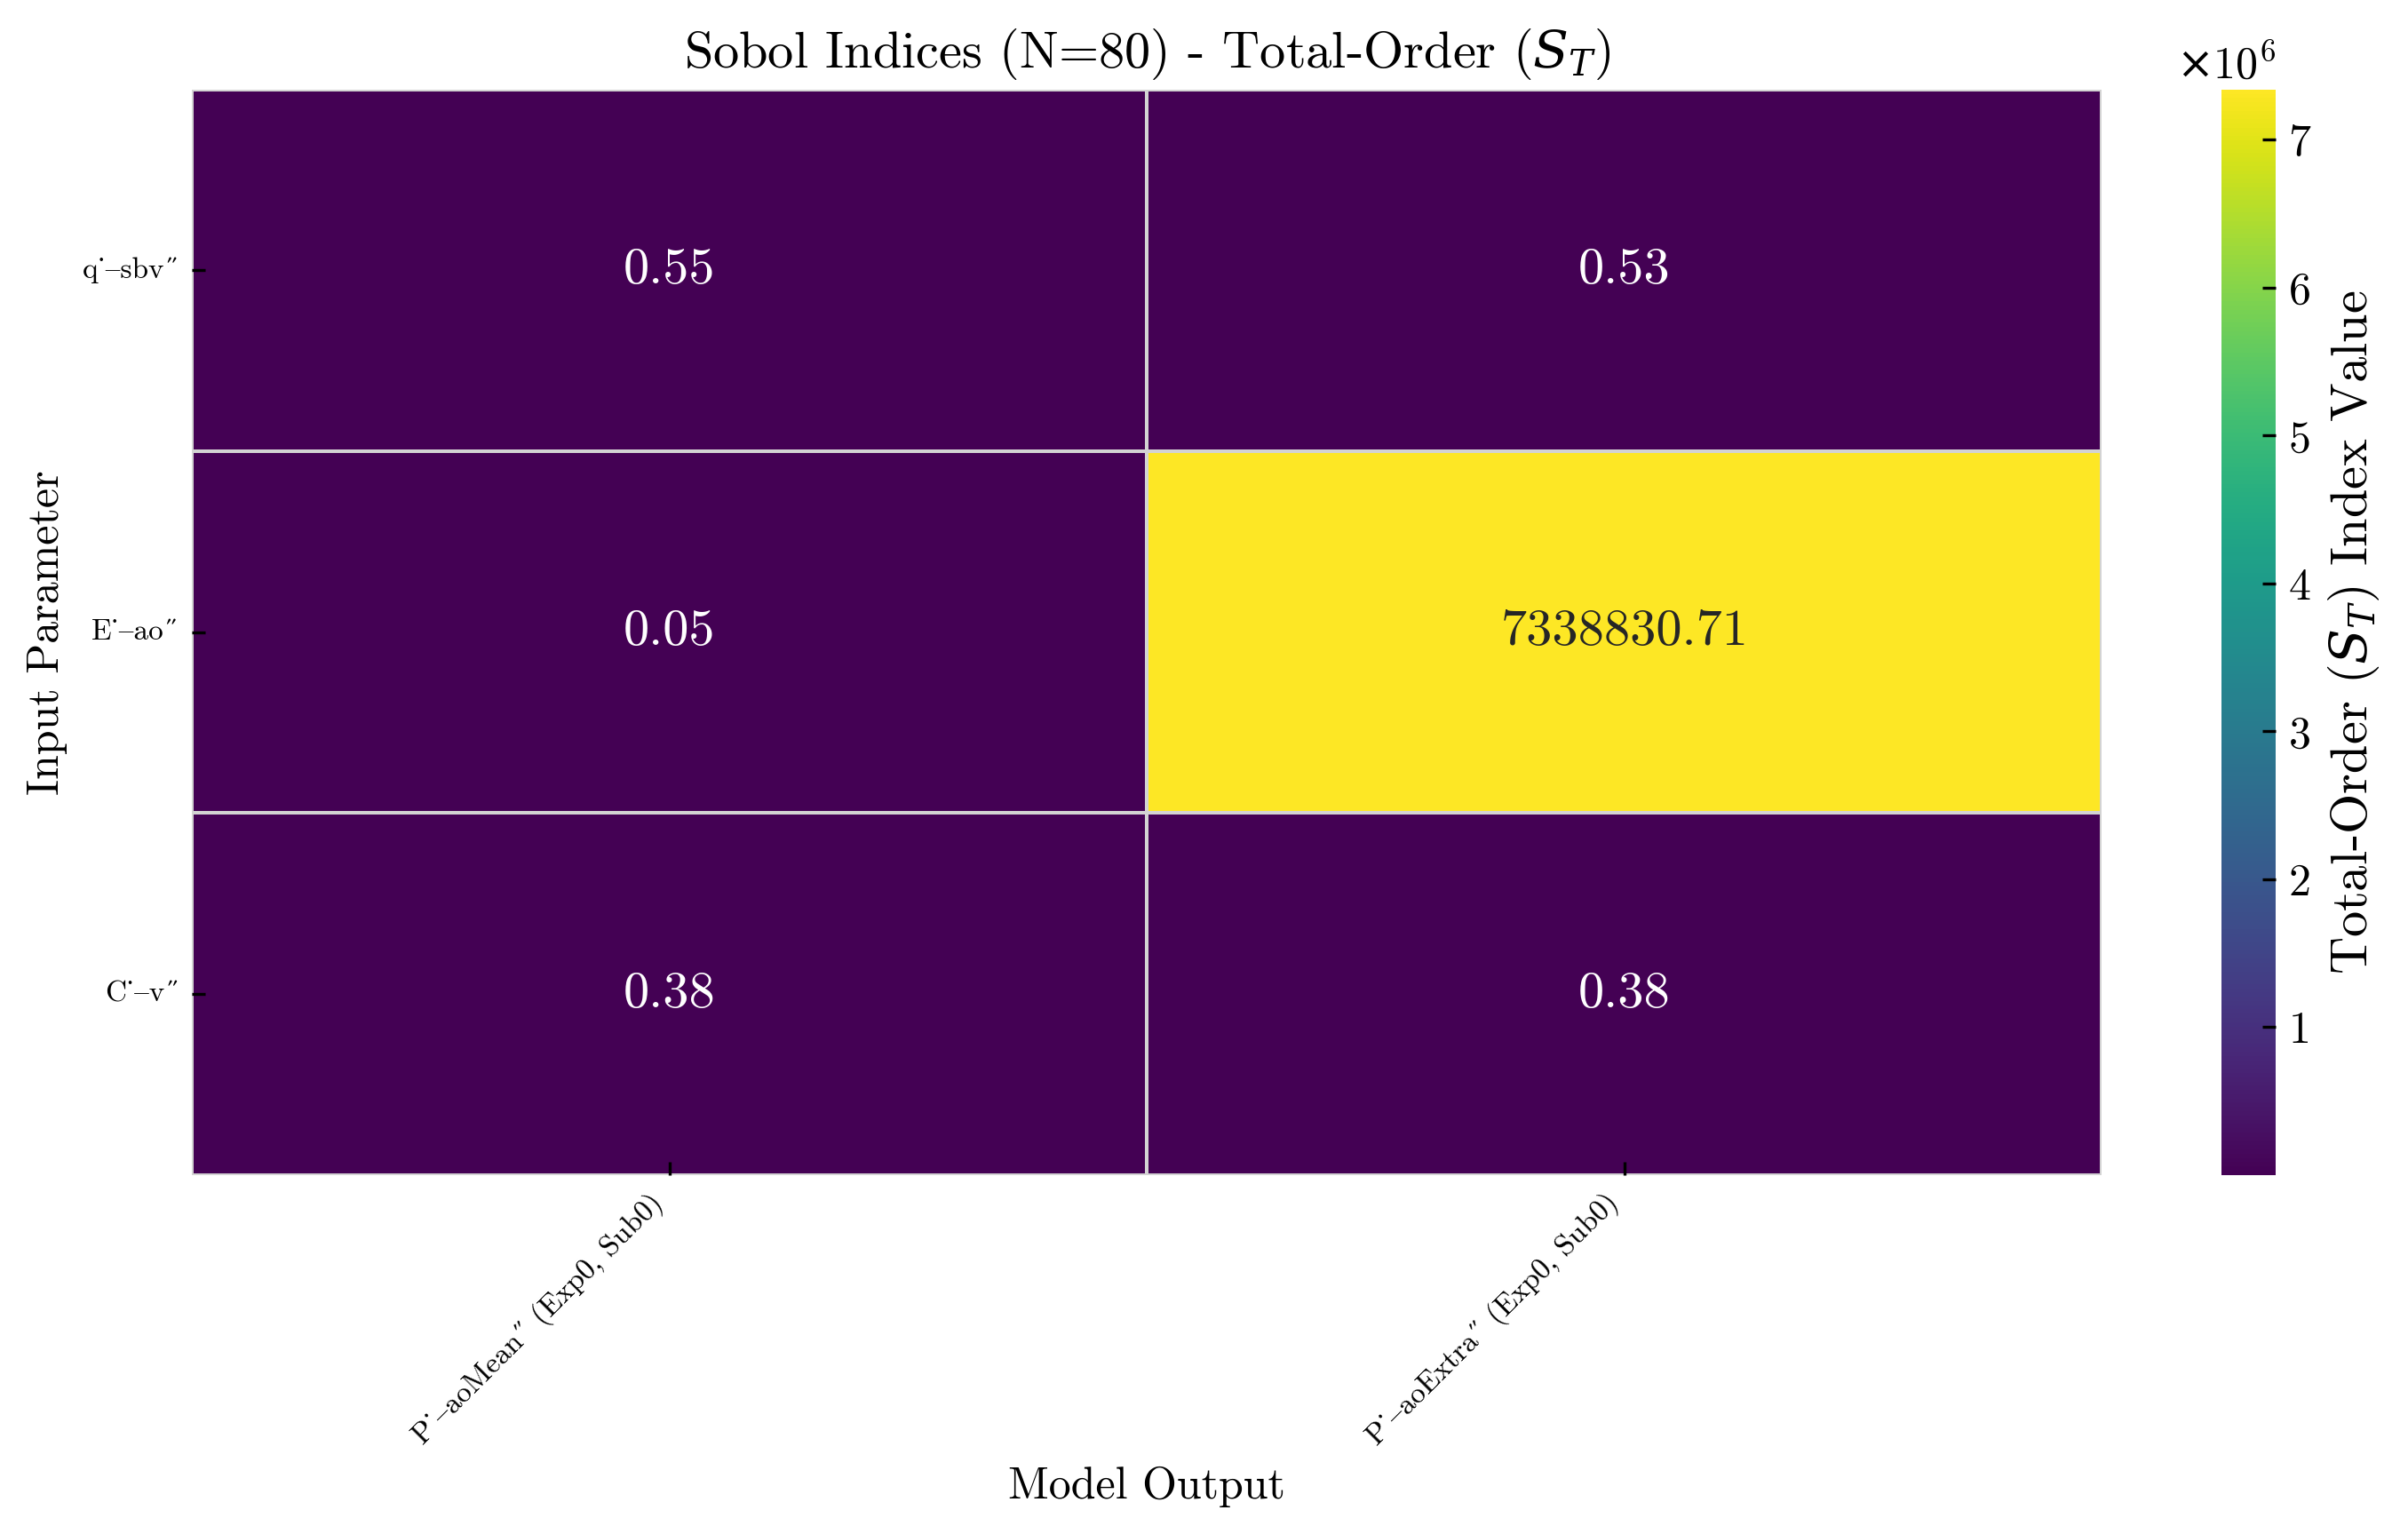

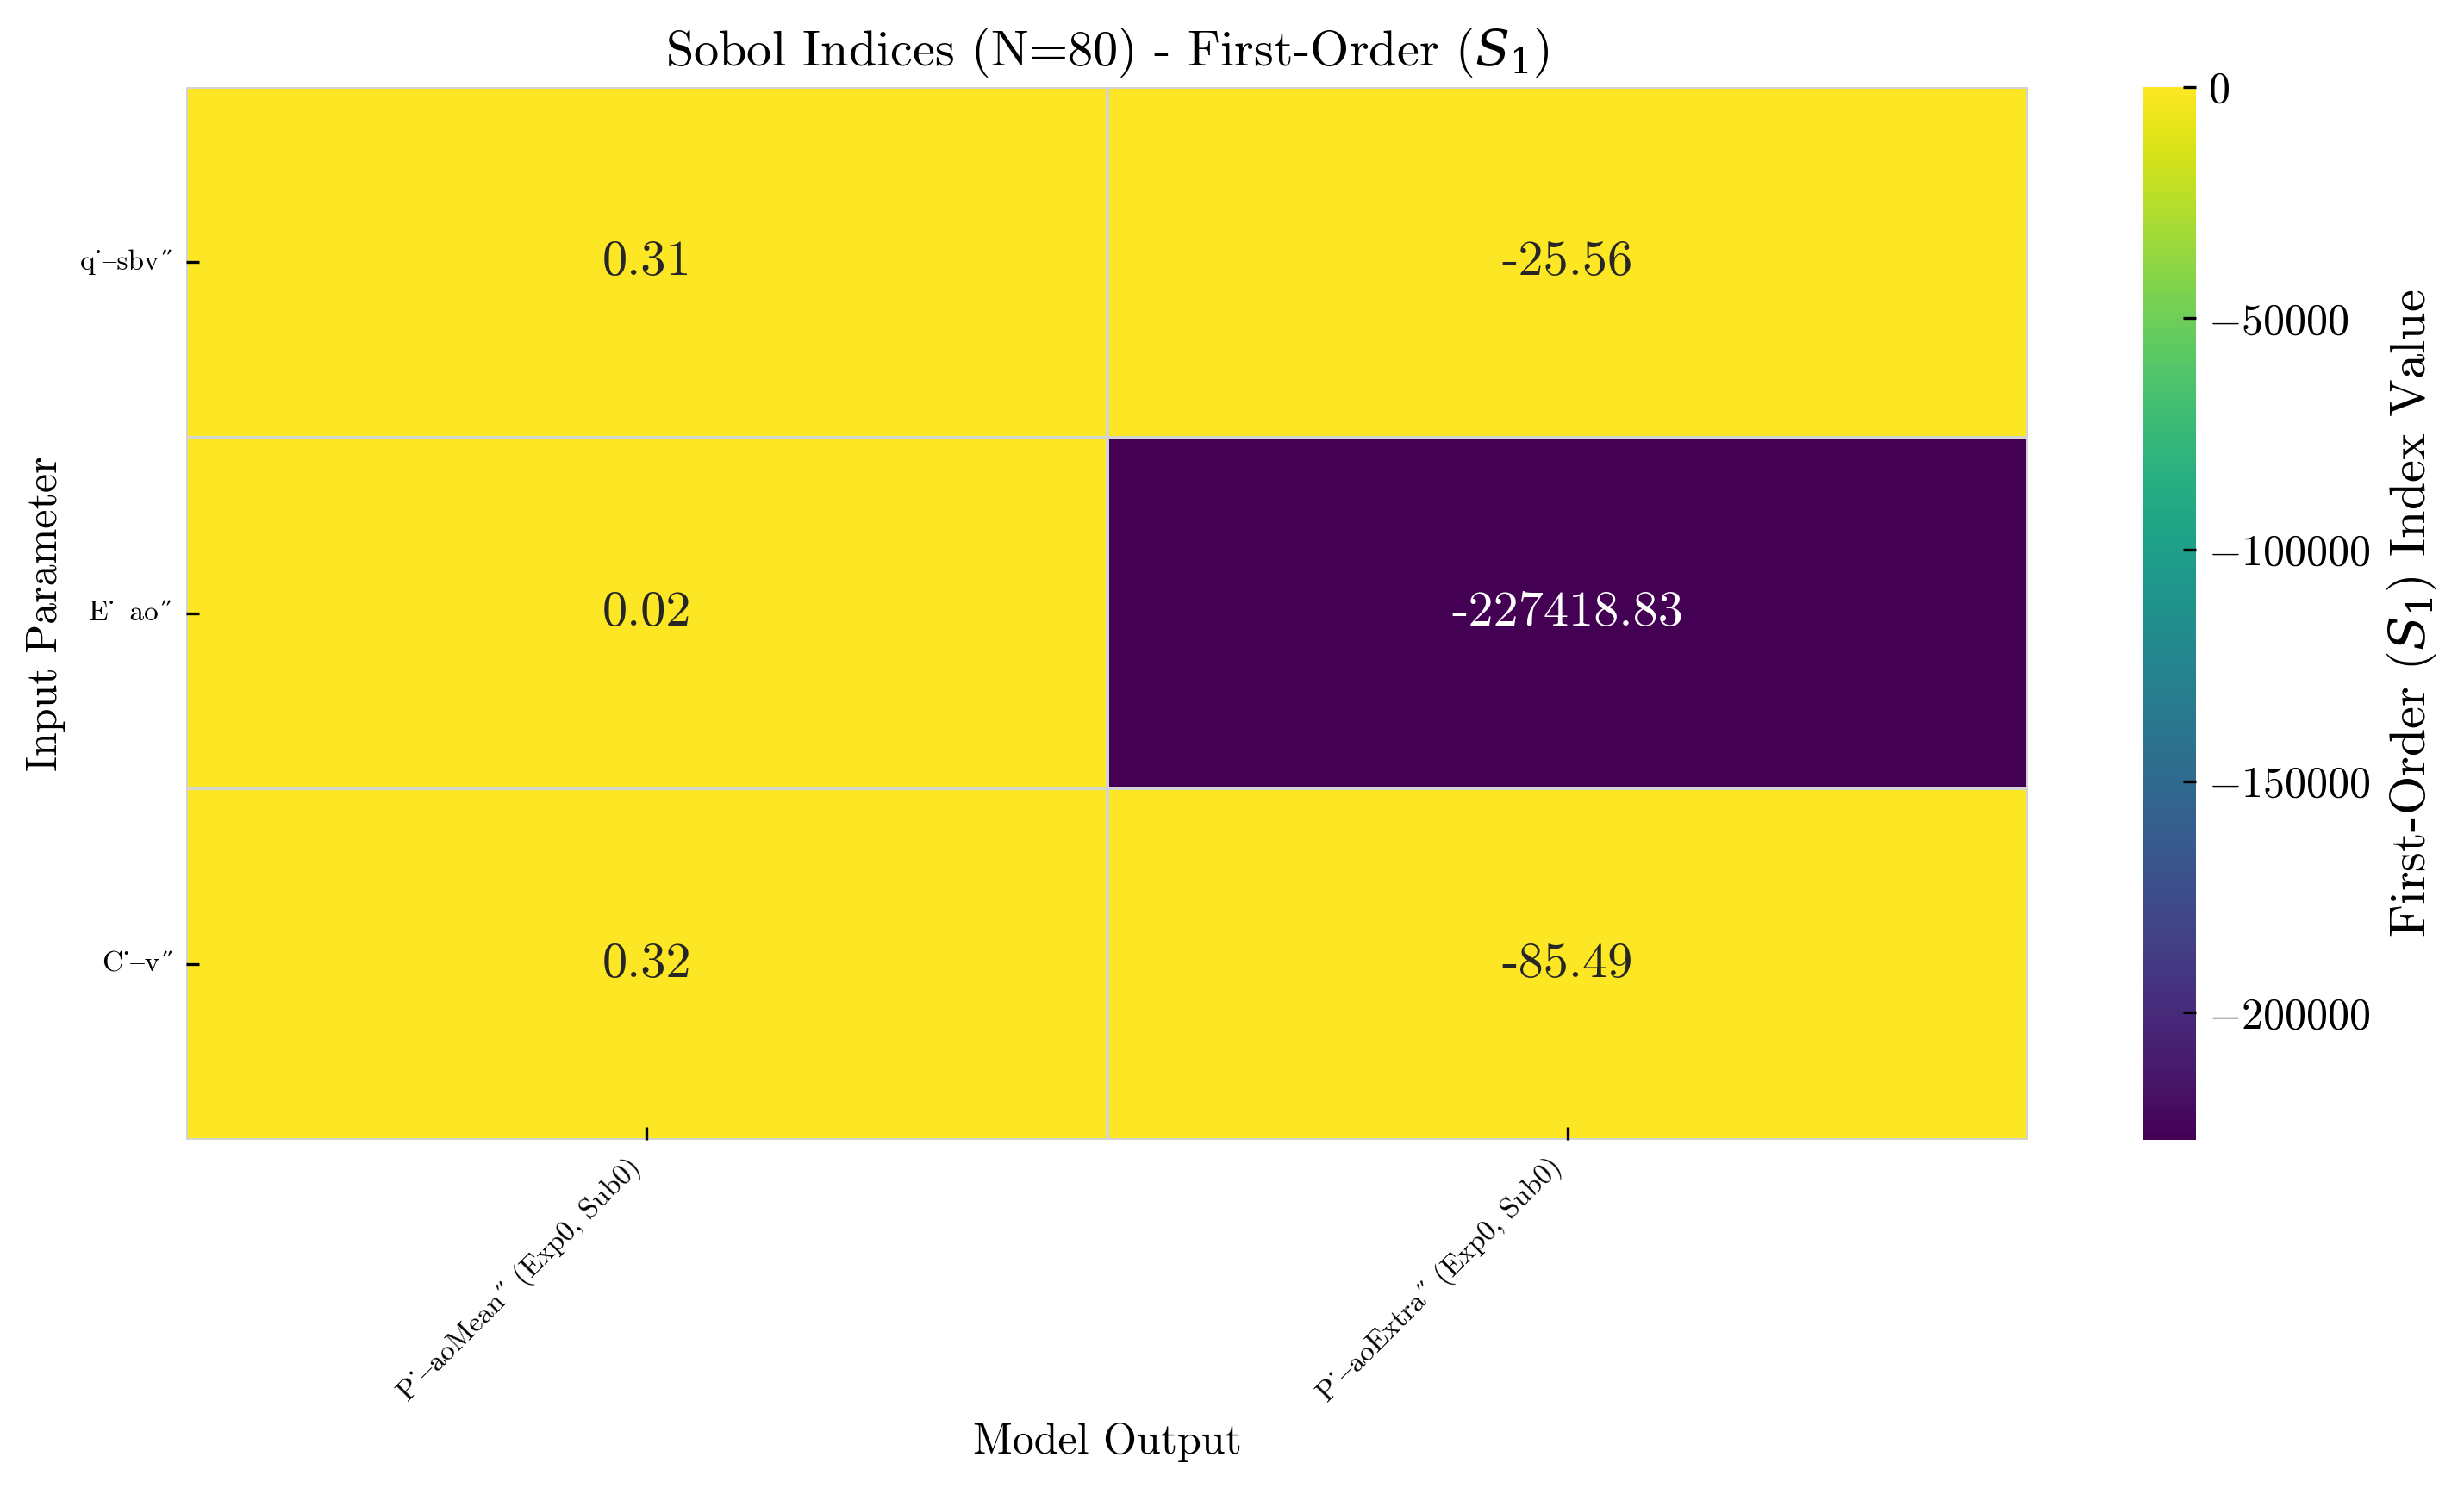

In [15]:

# Display the plots from the sensitivity analysis
plot_files = [file_path for file_path in sa_output_dir.glob("*.png")]
for plot_file in plot_files:
    display(Image(filename=str(plot_file)))

## 15) Choose influential parameters

Review the sensitivity analysis outputs (plots/arrays) to choose the most influential parameters (e.g., top 2).


In [16]:
# TODO: inspect SA outputs in sa_output_dir and pick top parameters
# Example placeholder list:
# most_influential_params = [
#     "global/q_lv_init"
# ]
# most_influential_params

most_influential_params = sa_agent.choose_most_impactful_params_sobol(top_n=2, index_type='ST', criterion='max', threshold=0.05, use_threshold=True)
# TODO the below needs to be done in the function
most_influential_param_names = [param.split("/")[-1] for param in most_influential_params]
most_influential_params


Selected 2 parameters (Criteria: max, Mode: filtered by threshold >= 0.05):
  1. K_tube_A_aorta_ascending_1/E        | Score: 7338830.7066
  2. global/q_lv_init                    | Score: 0.5487


['K_tube_A_aorta_ascending_1/E', 'global/q_lv_init']

## 16) Parameter identification (genetic algorithm)

Use the genetic algorithm to calibrate model parameters.

$$
\theta^{\star} = \arg\min_{\theta \in \Theta} \; \sum_{i=1}^{N} w_i \left\lVert \frac{z_i(\theta) - \hat{z_i}}{\sigma_i} \right\rVert^2
$$

where $\theta^{\star}$ is the best fit parameter vector, $\Theta$ is your parameter space, defined by the min and max you set in params_for_id_dict, $z_i$ are your output features, $\hat{z_i}$ are your ground truths for those features, $\sigma_i$ are your feature standard deviations, and $w_i$ are the weights for each feature.


In [17]:
from param_id.paramID import CVS0DParamID

inp_data_dict["param_id_method"] = "genetic_algorithm"
param_id.set_param_id_method(inp_data_dict["param_id_method"])

# Optimiser options (adjust as needed)
optimiser_options = {
    "num_calls_to_function": 1000,
    "cost_convergence": 0.001,
    "max_patience": 10,
    "cost_type": "MSE",
}

param_id.set_optimiser_options(optimiser_options)
param_id.set_ground_truth_data(obs_data_dict)

# TODO the below needs to be done in the function (not visible to user)
params_for_id_subset = [
    entry for entry in params_for_id_dict
    if entry["param_name"] in most_influential_param_names
]

param_id.set_params_for_id(params_for_id_subset)

# Run calibration
param_id.run()



Setting ground truth data: {'protocol_info': {'pre_times': [20], 'sim_times': [[0.8849]], 'params_to_change': {}, 'experiment_labels': ['exp_0'], 'num_experiments': 1, 'num_sub_per_exp': [1], 'num_sub_total': 1, 'total_sim_times_per_exp': [0.8849], 'tSims_per_exp': [array([0.        , 0.01005568, 0.02011136, 0.03016705, 0.04022273,
       0.05027841, 0.06033409, 0.07038977, 0.08044545, 0.09050114,
       0.10055682, 0.1106125 , 0.12066818, 0.13072386, 0.14077955,
       0.15083523, 0.16089091, 0.17094659, 0.18100227, 0.19105795,
       0.20111364, 0.21116932, 0.221225  , 0.23128068, 0.24133636,
       0.25139205, 0.26144773, 0.27150341, 0.28155909, 0.29161477,
       0.30167045, 0.31172614, 0.32178182, 0.3318375 , 0.34189318,
       0.35194886, 0.36200455, 0.37206023, 0.38211591, 0.39217159,
       0.40222727, 0.41228295, 0.42233864, 0.43239432, 0.44245   ,
       0.45250568, 0.46256136, 0.47261705, 0.48267273, 0.49272841,
       0.50278409, 0.51283977, 0.52289545, 0.53295114, 0.543006

In [18]:

# Plot best fit
# NOTE: `series_outputs` contains any available time-series used for observables.
obs_outputs, series_outputs = param_id.simulate_with_best_param_vals(return_series=True)
param_id.plot_outputs()

cost should be 10.377275556553837
cost check after single simulation is 10.377275556553837
final obs values :
subexperiment 1:
[1.22966035e+04 7.39741740e-01]
plotting best observables
______observable errors______
P_{aoMean} mean error:
2.11 %
P_{aoExtra} my_extra_feature error:
-5.58 %


## 17) Review calibration outputs

The calibration process saves plots and arrays in the parameter ID output directory. Use this section to view the plots. You can also make your own plots with the saved outputs.


Outputs saved to: /tutorials/tutorial_2_5_Argus_Ghitti_Davis/circulatory_autogen/src/parsers/../../param_id_output/genetic_algorithm_cvs_model_with_arm_0d_obs_20260210


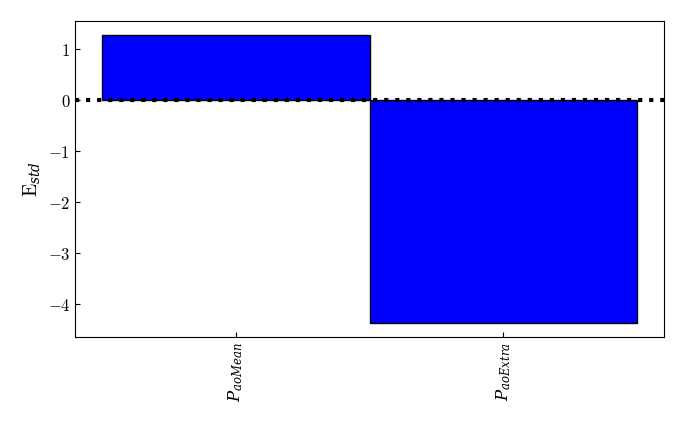

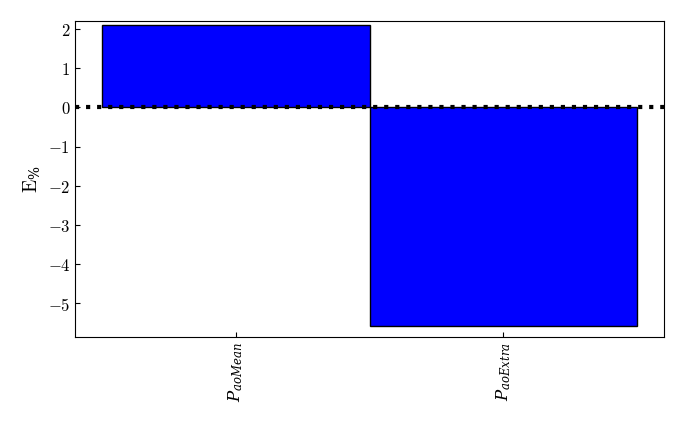

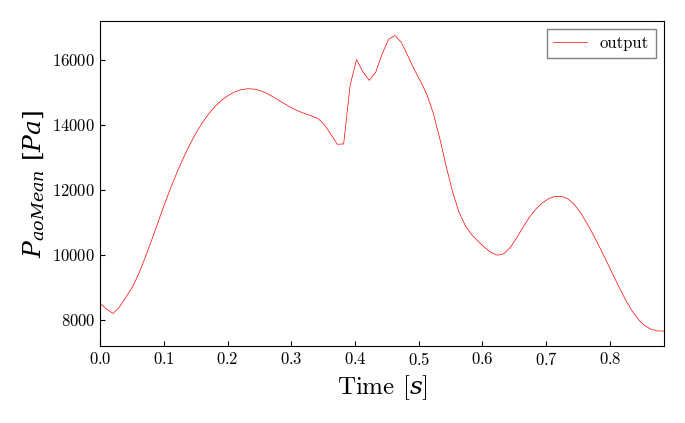

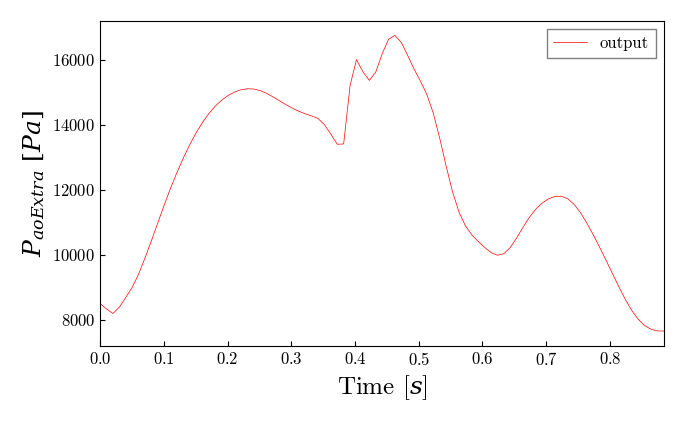

In [19]:
output_dir = Path(param_id.output_dir)
plot_dir = output_dir / "plots_param_id"
print("Outputs saved to:", output_dir)

# Example: load best parameters
best_params_path = output_dir / "best_param_vals.npy"
if best_params_path.exists():
    best_params = np.load(best_params_path)
    best_params
else:
    print("best_param_vals.npy not found")

# Display the plots from the param id
plot_files = [file_path for file_path in plot_dir.glob("*.png")]
for plot_file in plot_files:
    display(Image(filename=str(plot_file)))





In [20]:
# switch back to inline plotting
%matplotlib inline

In [21]:
series_outputs

[[array([ 8490.00648529,  8322.80397585,  8186.85820657,  8382.50462589,
          8681.8421232 ,  8990.39870353,  9399.7408225 ,  9894.92452664,
         10427.85435717, 10979.774097  , 11528.17129577, 12048.51870698,
         12531.96625819, 12978.84742361, 13387.44877576, 13753.31531736,
         14073.2506957 , 14346.45974124, 14573.49816161, 14756.15143189,
         14897.96014534, 15002.64084794, 15071.31740148, 15101.94481779,
         15091.9438695 , 15041.89096347, 14957.50904886, 14849.21789976,
         14729.83300363, 14611.50668935, 14502.87765866, 14408.74740935,
         14330.02672306, 14264.48209196, 14185.58611285, 13996.92966178,
         13704.56425388, 13393.92745722, 13402.42683269, 15198.58258433,
         15997.13824989, 15626.40957661, 15358.83441415, 15609.41473688,
         16167.34844344, 16622.18137764, 16742.66945062, 16525.97945892,
         16120.9950109 , 15701.95198348, 15330.15831422, 14918.11011946,
         14340.41559411, 13572.02326233, 12716.8219

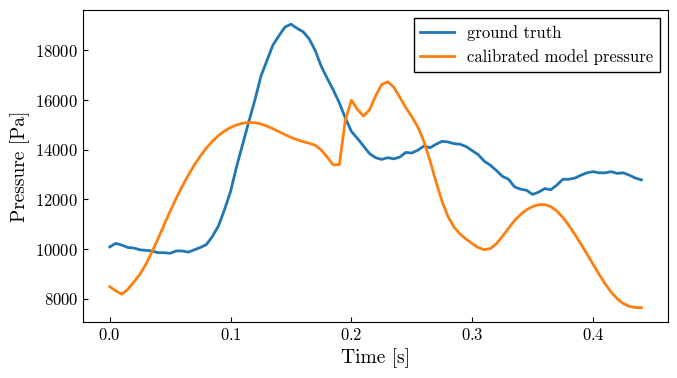

In [24]:
# === Extra plots ===
# Overlay the pressure series used for calibration (from `series_outputs`) vs the ground truth pressure.



subexp_idx = 0

p_model = np.asarray(series_outputs[0][0]).squeeze()
p_gt = np.asarray(pressure_pa).squeeze()
t_gt = np.asarray(time_gt).squeeze()

n = int(min(len(t_gt), len(p_gt), len(p_model)))

plt.figure(figsize=(7, 4))
plt.plot(t_gt[:n], p_gt[:n], label="ground truth", lw=2)
plt.plot(
    t_gt[:n],
    p_model[:n],
    label=f"calibrated model pressure",
    lw=2,
)
plt.xlabel("Time [s]")
plt.ylabel("Pressure [Pa]")
plt.legend()
plt.tight_layout()
plt.show()


## STOP TO IMPROVE CALIBRATION

- We know that the arterial elastance is important for fitting pulse pressure. How would you create a feature that is sensitive to $E$ but not to intial blood volume or venous compliance? 

## STUDENT TASK

- Try to improve the calibration pipeline by adding features to calibrate that aren't correlated (are close to orthogonal).

- After getting a good fit, answer again the following questions:

- What do you think are the most important features to fit to?
# -----------------------
-
-
-
# --------------------

- What parameters do you think affect each output feature?
# -----------------------
-
-
-
# --------------------

# Section C: Hybrid 1D-0D CVS model (STOP HERE FOR NOW)


## 18) Switch vessels of the arterial network to 1D.
- Create a list of the selected vessels to switch into 1D (Hint: all artery names in the CVS model start with "A_").
- Update the vessel array for the 1D-0D coupled model.


In [23]:
from scripts.convert_0d_to_1d import convert_0d_to_1d

# model_0d = model_name
model_0d = model_name_ext

# vess_1d_list = []
vess_1d_list = ['A_aorta_ascending_1', 'A_aorta_ascending_2', 'A_aorta_ascending_3', 'A_aorta_ascending_4',
                'A_aortic_arch_1', 'A_aortic_arch_2', 'A_aortic_arch_3', 'A_aortic_arch_4',
                'A_brachiocephalic_trunk',
                'A_common_carotid_L', 'A_common_carotid_R',
                'A_subclavian_L', 'A_subclavian_R',
                'A_aorta_thoracic_1', 'A_aorta_thoracic_2', 'A_aorta_thoracic_3', 'A_aorta_thoracic_4', 'A_aorta_thoracic_5',
                'A_aorta_abdominal_1', 'A_aorta_abdominal_2', 'A_aorta_abdominal_3', 'A_aorta_abdominal_4', 'A_aorta_abdominal_5', 'A_aorta_abdominal_6',
                'A_common_iliac_L', 'A_common_iliac_R']
if model_0d.endswith("_with_arm"):
    vess_1d_list.extend(['A_axillary_L', 'A_brachial_L', 'A_radial_L', 'A_ulnar_L',
                         'A_superficial_palmar_arch_L_1', 'A_superficial_palmar_arch_L_2',
                         'A_comm_palmar_digital_L_1', 'A_comm_palmar_digital_L_2', 'A_comm_palmar_digital_L_3'])
    
convert_0d_to_1d(model_0d, resources_dir, input_param_file, folder_hyb=None, vess_1d_list=vess_1d_list)


SystemExit: Error :: Vessel A_axillary_L not found in 0D vessel array for model cvs_model_with_arm.

/opt/OpenCOR/Python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## 19) Run the C++ model

- Regenerate the new C++ hybrid model with 1D arteries (the C++ 0D sub-model will be coupled to a Python 1D hemodynamic solver for the 1D arterial network).


In [ ]:
model_name_hyb = model_0d+"_hybrid"
file_prefix = model_name_hyb
input_param_file = f"{file_prefix}_parameters.csv"

inp_data_dict_hyb = get_default_inp_data_dict(file_prefix, input_param_file, resources_dir)

resources_dir_1d = CA_root / "files_1d"
if not os.path.exists(resources_dir_1d):
    os.makedirs(resources_dir_1d)
resources_subdir_1d = resources_dir_1d / model_name_hyb
if not os.path.exists(resources_subdir_1d):
    os.makedirs(resources_subdir_1d)
run_dir_1d = resources_subdir_1d / "run000"
if not os.path.exists(run_dir_1d):
    os.makedirs(run_dir_1d)
config_file_1d = run_dir_1d.joinpath("input.ini")

inp_data_dict_hyb['model_type'] = 'cpp'
inp_data_dict_hyb['solver_info']['solver'] = 'CVODE' # or 'PETSC'
inp_data_dict_hyb['solver_info']['method'] = inp_data_dict_hyb['solver_info']['solver']
inp_data_dict_hyb['couple_to_1d'] = True
inp_data_dict_hyb['create_main_0d'] = True
inp_data_dict_hyb['solver_1d_type'] = 'py'
inp_data_dict_hyb['generate_1d'] = True
inp_data_dict_hyb['model_1d_config_path'] = str(config_file_1d)

print('inp_data_dict_hyb set')
pprint.pprint(inp_data_dict_hyb)


In [ ]:
# Generate directly from resources CSVs
success_cpp = generate_with_new_architecture(inp_data_dict=inp_data_dict_hyb)

if not success_cpp:
    raise RuntimeError("Cpp Hybrid CVS Model generation failed")
else:
    print('Cpp Hybrid CVS Model generation successful!')
    

## 20) Run the C++ model

Run the C++ model.

Option: Use `subprocess` to run the compiled binary for the 0D-1D hybrid.

## TODO Bea
Add steps here on how to run the hybrid model extrernally from this Jupyter notebook (bash script?)

In [ ]:
import subprocess

# TODO: update binary path and arguments
cpp_run_dir = Path(inp_data_dict_cpp.get("cpp_generated_models_dir", generated_models_dir / file_prefix))
cpp_binary = cpp_run_dir / "run_model"  # placeholder

# we need a step here to call the building of the cpp model
# OR WE DO THIS IN TERMINAL AND PROVIDE INSTRUCTIONS


# now run the cpp executable.
if cpp_binary.exists():
    result = subprocess.run([str(cpp_binary)], cwd=str(cpp_run_dir), capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
else:
    print(f"C++ binary not found: {cpp_binary}")


## 21) Load and plot 0D-1D hybrid results

- Load the 0D-1D hybrid outputs.
- Plot and compare 0D-1D vs 0D results.

## TODO Bea

In [ ]:
# TODO: update with real hybrid output file(s)
hybrid_output_csv = cpp_run_dir / "hybrid_outputs.csv"

if hybrid_output_csv.exists():
    hybrid = pd.read_csv(hybrid_output_csv)
    time_col = "time"  # TODO: update
    hybrid_var = "aortic_root/u"  # TODO: update

    plt.figure(figsize=(6, 4))
    plt.plot(t, y[2], label="0D")
    plt.plot(hybrid[time_col], hybrid[hybrid_var], label="0D-1D hybrid")
    plt.xlabel("Time [s]")
    plt.ylabel(hybrid_var)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Hybrid output not found: {hybrid_output_csv}")


## 22) PWV comparison (0D vs 0D-1D)

- Compute pulse wave velocity (PWV) from 0D outputs.
- Compute PWV ffrom the hybrid.
- Compare them.

## TODO Bea

In [ ]:
# Add your preferred PWV computation here.
# TODO: compute PWV from 0D outputs
# pwv_0d = compute_pwv(sim_helper, ...)

In [ ]:
# TODO: compute PWV from hybrid outputs
# pwv_hybrid = compute_pwv_from_hybrid(hybrid)

# Compare PWV values
# print("PWV 0D:", pwv_0d)
# print("PWV hybrid:", pwv_hybrid)
